# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [252]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import libraries

In [253]:
df=pd.read_csv(
    r"C:\Users\user\dsc-course0-m8-lab\aviation_cleaned_stage1.csv",
    encoding="ISO-8859-1",
    low_memory=False
)
df.head()

,event_id,investigation_type,accident_number,event_date,location,country,latitude,longitude,injury_severity,aircraft_damage,...,broad_phase_of_flight,publication_date,total_passengers,fatal_injury_rate,serious_injury_rate,severe_injury_rate,was_destroyed,Make,base_model,aircraft_type
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,Incident,minor,...,taxi,04-12-2014,588.0,0.0,0.0,0.0,0,boeing,747,boeing_747
1,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,Fatal(1),unknown,...,standing,17-10-2016,5.0,0.2,0.0,0.2,0,de havilland,dhc-6,de havilland_dhc-6
2,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,NaN,NaN,Incident,minor,...,taxi,11-06-2018,100.0,0.0,0.0,0.0,0,boeing,727,boeing_727
3,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,Non-Fatal,substantial,...,climb,05-05-2011,1.0,0.0,0.0,0.0,0,beech,c35,beech_c35
4,20001214X45339,Accident,LAX84LA110,1983-12-22,"SANTA ROSA ISLAND, CA",United States,NaN,NaN,Non-Fatal,substantial,...,takeoff,01-02-2016,1.0,0.0,0.0,0.0,0,cessna,180,cessna_180


import dataset

In [254]:
df.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'injury_severity',
       'aircraft_damage', 'aircraft_category', 'registration_number', 'make',
       'model', 'amateur_built', 'number_of_engines', 'engine_type',
       'far_description', 'purpose_of_flight', 'total_fatal_injuries',
       'total_serious_injuries', 'total_minor_injuries', 'total_uninjured',
       'weather_condition', 'broad_phase_of_flight', 'publication_date',
       'total_passengers', 'fatal_injury_rate', 'serious_injury_rate',
       'severe_injury_rate', 'was_destroyed', 'Make', 'base_model',
       'aircraft_type'],
      dtype='object')

check the coulumn names

In [255]:
df['total_fatal_injuries'].isnull().sum()

0

confirm whether we still have missing values

importing libraries

## Exploratory Data Analysis  
- Load in the cleaned data

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

creating aircraft size column to differenciate eiter small or large using the total number of passangers

In [256]:
df["aircraft_size"] = df["total_passengers"].apply(
    lambda x: "small" if x < 20 else "large"
)
df["aircraft_size"].values

array(['large', 'small', 'large', ..., 'small', 'small', 'small'],
      dtype=object)

decided that the small plane should cary 20 passangers more that that should be a large plane

creating a safety score, to get the total number of injuries column

In [257]:
df["total_injuries"] = (
    df["total_fatal_injuries"] +
    df["total_serious_injuries"] +
    df["total_minor_injuries"]
)
df["total_injuries"].sum()

18008.0

there are 18008 total number of injuries

now , analysis of safety per airplane make
groupby aircraft size and its make

In [323]:
safety_per_make = df.groupby(["aircraft_size", "make"]).agg({
    "total_fatal_injuries": "sum",
    "total_serious_injuries": "sum",
    "total_minor_injuries": "sum",
    "fatal_injury_rate": "sum",
    "total_injuries": "sum",
    "event_id": "count"   # number of incidents
}).rename(columns={"event_id": "total_accidents"}).reset_index()
safety_per_make.min()

aircraft_size                      large
make                      aero commander
total_fatal_injuries                 0.0
total_serious_injuries               0.0
total_minor_injuries                 0.0
fatal_injury_rate                    0.0
total_injuries                       5.0
total_accidents                        1
dtype: object

Grouping airplanes by their size and brand, counting how many accidents and injuries they had, and then checking which one had the biggest (worst) number
we get that small aircraft, make taylorcraft got the highest number of inuries 

ploting the safest aircraft

separate small and large aircraft

In [259]:
small_aircraft = safety_per_make[safety_per_make["aircraft_size"] == "small"]
large_aircraft = safety_per_make[safety_per_make["aircraft_size"] == "large"]

finding the safest aircraft which has low fatality rate and not so many accidents

In [260]:
small_aircraft
small_safest = small_aircraft.sort_values(
    by=["fatal_injury_rate", "total_accidents"],
    ascending=True 
).head(10)


In [261]:
#the safest large_aircraft
large_safest = large_aircraft.sort_values(
    by=["fatal_injury_rate", "total_accidents"]
).head(10)

Which small and large aircraft makes are the safest based on injury rate and accident frequency

ploting the safest aircraft for small aircraft to check which make has the highest and smallest fatality rate( how deadly accidents are for  a given aircraft)i will only recomend aircraft with low fatality rate

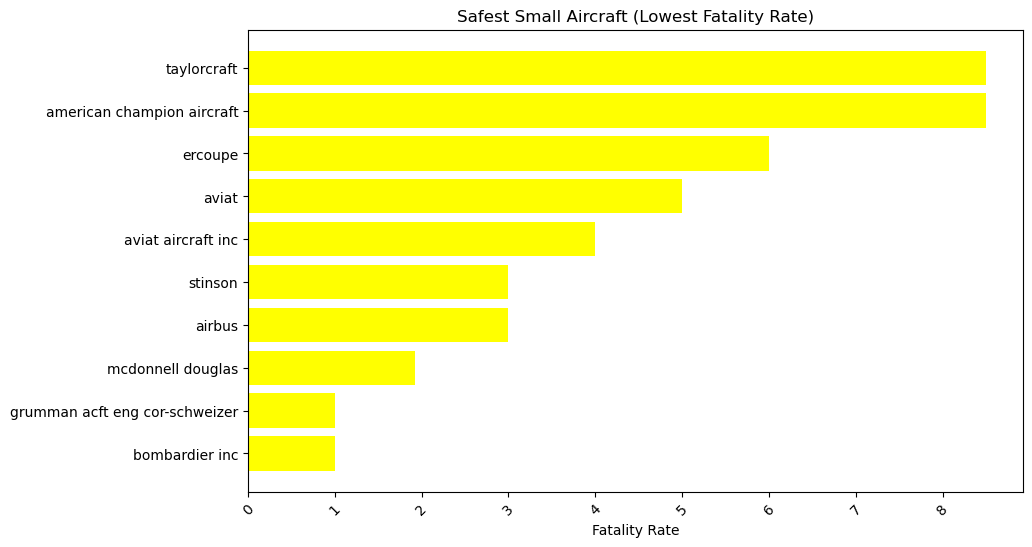

In [262]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.xticks(rotation=45)  
plt.barh(small_safest["make"], small_safest["fatal_injury_rate"],color="yellow")
plt.title("Safest Small Aircraft (Lowest Fatality Rate)")
plt.xlabel("Fatality Rate")
plt.show()

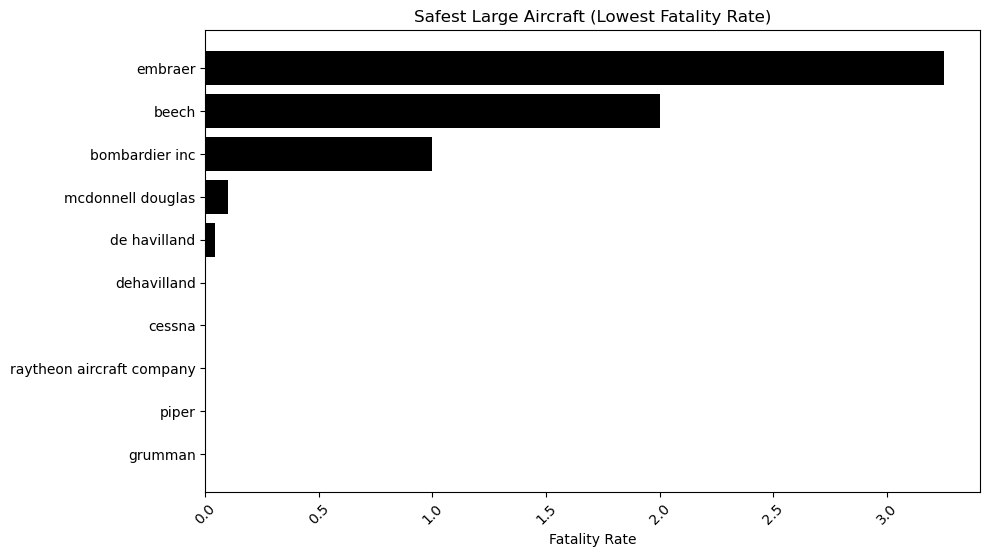

In [263]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.xticks(rotation=45)  
plt.barh(large_safest ["make"], large_safest ["fatal_injury_rate"],color="black")
plt.title("Safest Large Aircraft (Lowest Fatality Rate)")
plt.xlabel("Fatality Rate")
plt.show()

fatality rate tells us how deadly accidents are for  a given aircraft hence embraer has the deadly accidents ;and macdonell douglas has the lowest has the lowest deeadliy accident rates
i would not recommend embraer

Which small and large aircraft makes are the safest based on injury rate and accident frequency
I come to agreeeement that dehavilland a large airlane and bombardier inc are the safest based on the inury rate  and accident frequency

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

creating a combined risk metric of serious injuries and fatal injury rate

In [264]:
df["serious_injury_rate"] = df["total_serious_injuries"] / df["total_injuries"]

df["fatal_serious_fraction"] = df["fatal_injury_rate"] + df["serious_injury_rate"]# Combine risk (fatal + serious)

In [265]:
#grouping my data
safety_per_make = df.groupby(["aircraft_size", "make"]).agg({
    "fatal_serious_fraction": "mean",
    "event_id": "count"
}).rename(columns={"event_id": "total_accidents"}).reset_index()

trying to weigh how dangerous the accedent was

filtering the top 15 safest aircraft per make

In [267]:
# Small aircraft
small_safe = (
    safety_per_make[safety_per_make["aircraft_size"] == "small"]
    .sort_values("fatal_serious_fraction")
    .head(15)
)


In [268]:
# Large aircraft
large_safe = (
    safety_per_make[safety_per_make["aircraft_size"] == "large"]
    .sort_values("fatal_serious_fraction")
    .head(15)
)

In [269]:
#ploting side by side

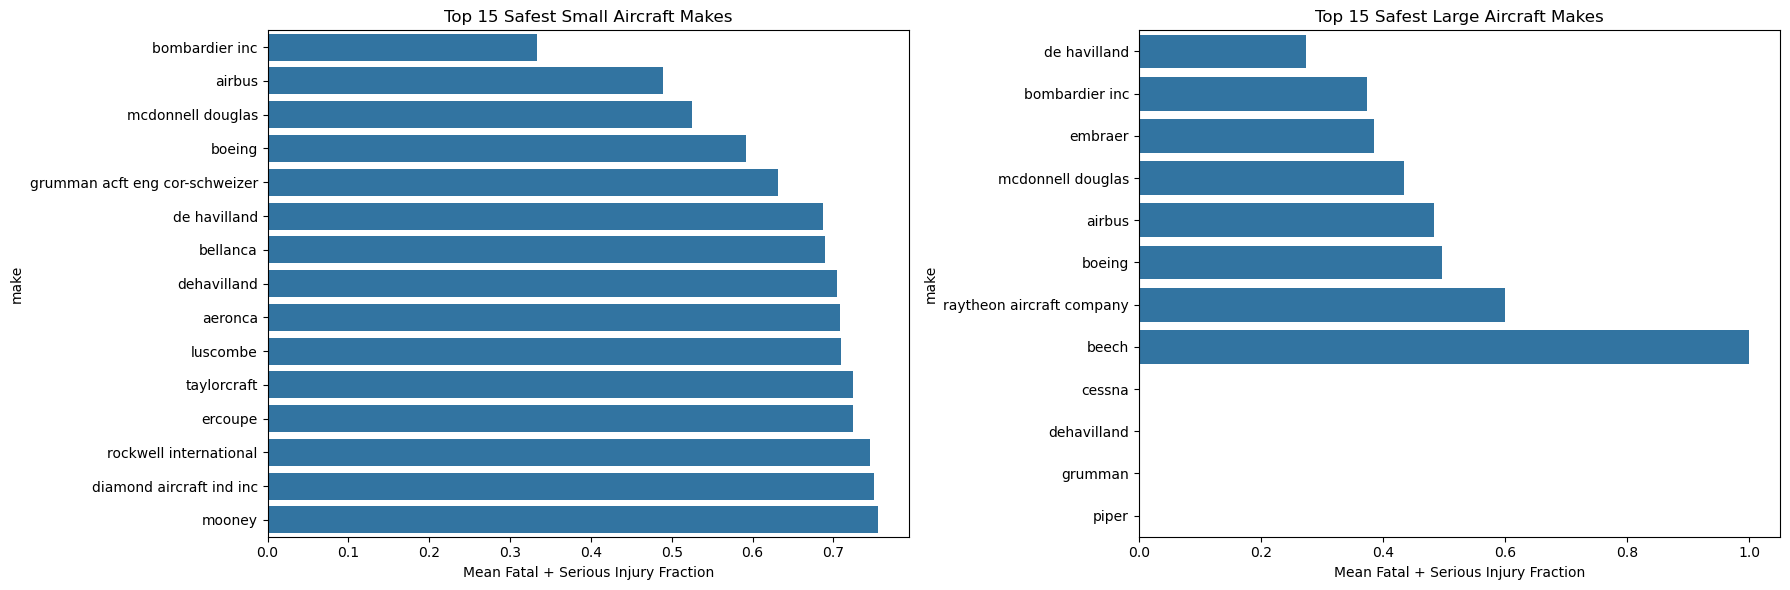

In [270]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Small aircraft plot
sns.barplot(
    data=small_safe,
    x="fatal_serious_fraction",
    y="make",
    ax=axes[0]
)
axes[0].set_title("Top 15 Safest Small Aircraft Makes")
axes[0].set_xlabel("Mean Fatal + Serious Injury Fraction")

# Large aircraft plot
sns.barplot(
    data=large_safe,
    x="fatal_serious_fraction",
    y="make",
    ax=axes[1]
)
axes[1].set_title("Top 15 Safest Large Aircraft Makes")
axes[1].set_xlabel("Mean Fatal + Serious Injury Fraction")

plt.tight_layout()
plt.show()

for small aircraft i would recommend bombardier inc with the smallest serious injury fraction and mean fatal
for large aircraft i would recommend de havilland  with the smallest serious injury fraction and mean fatal
         i measure human risk, not just accidents
combine:
  Fatal injuries
  Serious injuries
  Then average per make
  Lower value = safer aircraft

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

create injury fraction

In [271]:
df["serious_injury_rate"] = df["total_serious_injuries"] / df["total_injuries"]

df["fatal_serious_fraction"] = (
    df["fatal_injury_rate"] + df["serious_injury_rate"]
)

In [272]:
#filter small aircraft
small_df = df[df["aircraft_size"] == "small"]

getting top 10 safest make

In [273]:
top10_safe_makes = (
    small_df.groupby("make")["fatal_serious_fraction"]
    .mean()
    .sort_values()
    .head(10)
    .index
)
small_top10 = small_df[small_df["make"].isin(top10_safe_makes)]

ploting using violinplot

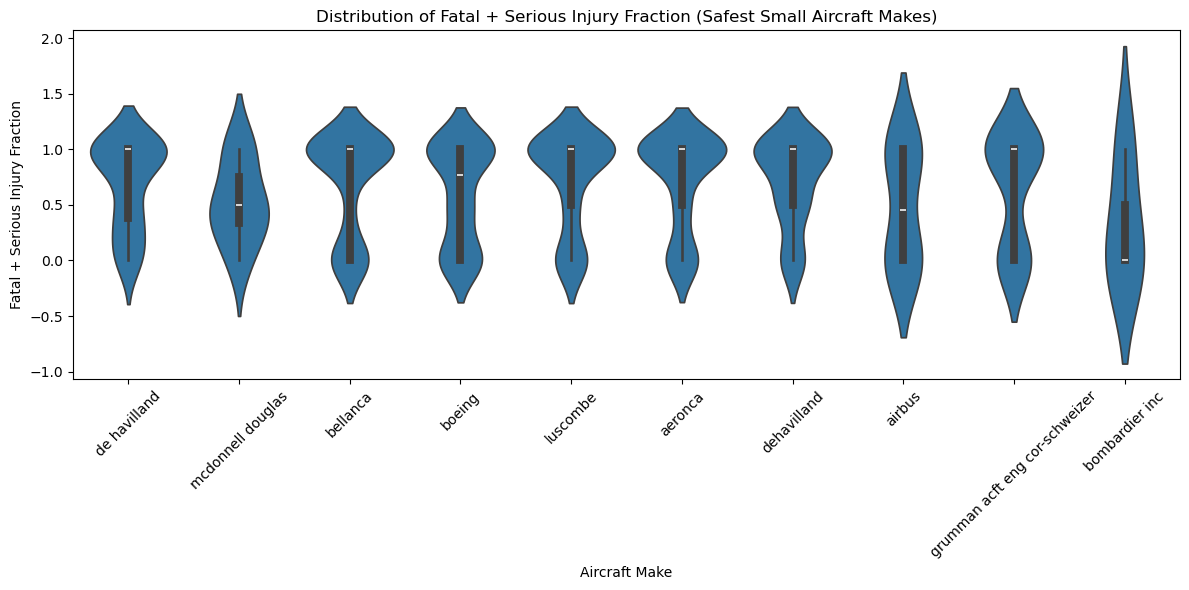

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=small_top10,
    x="make",
    y="fatal_serious_fraction"
)

plt.title("Distribution of Fatal + Serious Injury Fraction (Safest Small Aircraft Makes)")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal + Serious Injury Fraction")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

While several small aircraft manufacturers show low average injury rates, the distribution analysis reveals that many still experience highly severe incidents. The safest manufacturers are those with not only lower average injury fractions but also more consistent outcomes across incidents hence ill recommend airbus,mcdonnell and  douglas 

I will also recommend bombardier inc, most accidents involving these aircrafts result in less severe inuries

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [275]:
#creating fatal serious fraction
df["fatal_serious_fraction"] = (
    df["total_fatal_injuries"] + df["total_serious_injuries"]
) / df["total_injuries"]

# Handle division by zero
df["fatal_serious_fraction"] = df["fatal_serious_fraction"].fillna(0)

In [276]:
import seaborn as sns
import matplotlib.pyplot as plt

large_df = df[df["aircraft_size"] == "large"]# Filter large aircraft


large_means = (
    large_df.groupby("make")["fatal_serious_fraction"]
    .mean()
    .sort_values()
    .head(10)   # 10 safest (lowest rates)#  Compute mean fatal + serious injury fraction per make
)

large_safest = large_df[large_df["make"].isin(large_means.index)]#  Filter dataset to only those makes




using stripplot to look at the distribution of the passangers serious/fatally injured for large airplane makes

In [277]:
large_safest.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'injury_severity',
       'aircraft_damage', 'aircraft_category', 'registration_number', 'make',
       'model', 'amateur_built', 'number_of_engines', 'engine_type',
       'far_description', 'purpose_of_flight', 'total_fatal_injuries',
       'total_serious_injuries', 'total_minor_injuries', 'total_uninjured',
       'weather_condition', 'broad_phase_of_flight', 'publication_date',
       'total_passengers', 'fatal_injury_rate', 'serious_injury_rate',
       'severe_injury_rate', 'was_destroyed', 'Make', 'base_model',
       'aircraft_type', 'aircraft_size', 'total_injuries',
       'fatal_serious_fraction'],
      dtype='object')

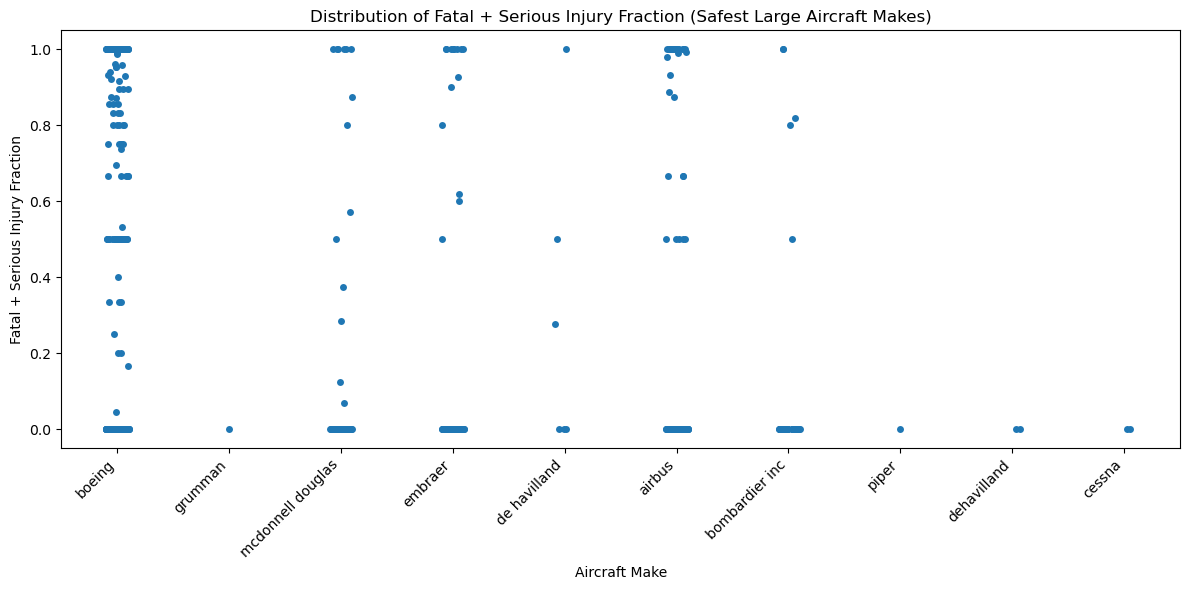

In [278]:
plt.figure(figsize=(12, 6))

sns.stripplot(
    data=large_safest,
    x="make",
    y="fatal_serious_fraction",
    jitter=True   # spreads points so they don’t overlap
)

plt.xticks(rotation=45, ha="right")  # rotate labels
plt.title("Distribution of Fatal + Serious Injury Fraction (Safest Large Aircraft Makes)")
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal + Serious Injury Fraction")

plt.tight_layout()
plt.show()

Across major aircraft manufacturers, accident severity varies widely, with most incidents resulting in no serious injuries, but a noticeable number reaching maximum severity. Larger manufacturers show greater variability, likely due to higher exposure and diverse operating conditions.dots clustered at 1 shows there were serious inuries and 0 shows otherwise

I will  recommend bombardier inc, most accidents involving these aircrafts result in less severe inuries, I cannot recommend piper dehavillland and cessna , mybe because they might not be in demand but since they show low accident rate you can try

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

sort based on large aircraft

create a destructive indicator

In [279]:
df["is_destroyed"] = (df["aircraft_damage"] == "Destroyed").astype(int)

group by size and make

In [280]:
destruction_rate = (
    df.groupby(["aircraft_size", "make"])
    .agg(
        destruction_rate=("is_destroyed", "mean"),
        total_accidents=("event_id", "count")
    )
    .reset_index()
)

In [281]:
destruction_df = df.groupby(["aircraft_size", "make"]).agg({
    "aircraft_damage": lambda x: (x.str.lower() == "destroyed").mean(),
    "event_id": "count"
}).rename(columns={
    "aircraft_damage": "destruction_rate",
    "event_id": "total_accidents"
}).reset_index()
df["aircraft_damage"].value_counts()#double checking

aircraft_damage
substantial    13698
destroyed       1586
unknown          721
minor            463
Name: count, dtype: int64

above I am measuring how risky aircraft is depending on the make and size by getting the number of destroyed,substantial and others airplane

separating small and large

In [282]:
small_destruction = destruction_df[
    destruction_df["aircraft_size"] == "small"
].sort_values("destruction_rate").head(15)

In [283]:
#see reesult
print("Safest SMALL aircraft (lowest destruction rate):")
display(small_destruction)

print("\nSafest LARGE aircraft (lowest destruction rate):")
display(large_destruction)

Safest SMALL aircraft (lowest destruction rate):


,aircraft_size,make,destruction_rate,total_accidents
35,small,luscombe,0.014815,135
44,small,stinson,0.015873,126
34,small,grumman acft eng cor-schweizer,0.017241,58
36,small,maule,0.033654,208
45,small,taylorcraft,0.034091,88
13,small,aeronca,0.036458,192
17,small,american champion aircraft,0.038462,52
21,small,bellanca,0.038462,208
32,small,ercoupe,0.039216,51
19,small,aviat aircraft inc,0.039474,76



Safest LARGE aircraft (lowest destruction rate):


,aircraft_size,make,destruction_rate,total_accidents
4,large,cessna,0.000000,2
5,large,de havilland,0.000000,6
6,large,dehavilland,0.000000,2
8,large,grumman,0.000000,1
10,large,piper,0.000000,1
11,large,raytheon aircraft company,0.000000,1
3,large,bombardier inc,0.022727,44
2,large,boeing,0.040590,542
7,large,embraer,0.051282,78
0,large,airbus,0.068376,117


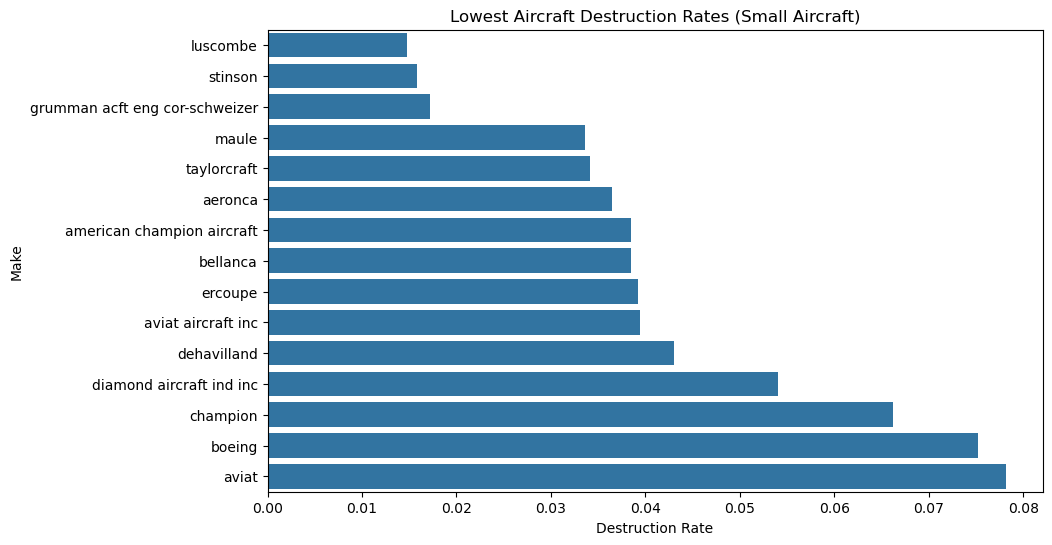

In [328]:
#visualizing small aircraft
plt.figure(figsize=(10, 6))
sns.barplot(data=small_destruction, x="destruction_rate", y="make")
plt.title("Lowest Aircraft Destruction Rates (Small Aircraft)")
plt.xlabel("Destruction Rate")
plt.ylabel("Make")
plt.savefig("visualizations/destruction_rates.png")
plt.show()

luscombe has the smallest rate of destruction compared to aviat

when checking the airplane make with the lowest destruction rate i will recommend luscombe for small aircraft

In [285]:
destruction_df = df.groupby(["aircraft_size", "make"]).agg({
    "aircraft_damage": lambda x: (x.str.lower() == "destroyed").mean(),
    "event_id": "count"
}).rename(columns={
    "aircraft_damage": "destruction_rate",
    "event_id": "total_accidents"
}).reset_index()

In [286]:
large_destruction = (
    destruction_df[destruction_df["aircraft_size"].str.lower() == "large"]
    .dropna(subset=["destruction_rate"])
    .sort_values("destruction_rate")
    .head(15)
)

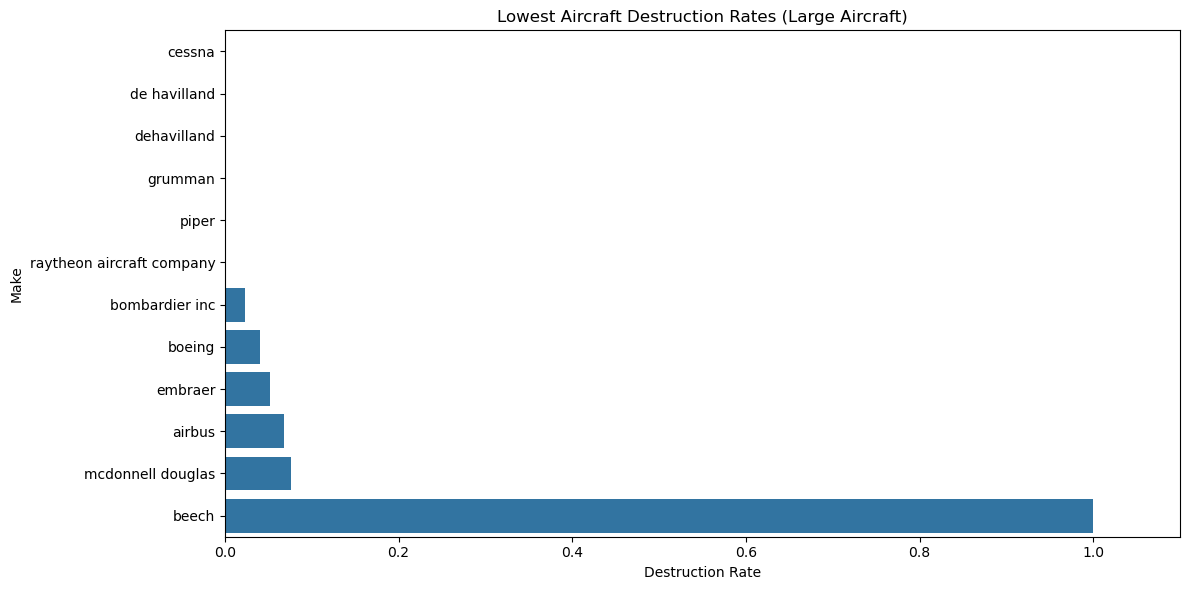

In [288]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=large_destruction,
    x="destruction_rate",
    y="make"
)

plt.title("Lowest Aircraft Destruction Rates (Large Aircraft)")
plt.xlabel("Destruction Rate")
plt.ylabel("Make")
plt.xticks(rotation=0)
plt.xlim(0, large_destruction["destruction_rate"].max() * 1.1)

plt.tight_layout()
plt.show()

bombardier inc has the lowest rate of destruction

hence i will recommend bombardier

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

 i found out that we have a ttotal of 18008 total number of inuries accross all planes.A small aairplane of make taylorcraft had the highest number of total fatal inuries of 2538and 23577 total number of accidents, a large airplane make aero commander had the smallest number of injuries of 5 and 1 accident occurence.

 Based on the injury rate and accident frequency ,small airplane bombadier inc is the safest and a large aiirplane de havilland is the safest.this is visualized using a bar graph

 Checking human injury risk,bombadier inc of small size and de havilland of large make had low number of mean fatal and serious injury fraction,this was visualized using a bar grapgh and filtering the top 15 safest aircrafts.

 Accoding to the distribution of injuty rate and using violinplot and filtering 10 best safest aircrafts,i will recommend bombadier inc for small size and de havilland for large size because accidents involving these aircrafts resulted in less server injuries

 when evaluating the rate of destruction i realized that luscombe luscombe got the lowest rate of destruction for small aircraft and bombadier inc for large size

 i will highly recommend bombadier inc and de havilland

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

creating the safety metric

In [289]:
df["fatal_serious_fraction"] = (
    df["total_fatal_injuries"] + df["total_serious_injuries"]
) / df["total_passengers"]

In [290]:
#filter valid make atleast 10
valid_makes = df.groupby("make")["event_id"].count()
valid_makes = valid_makes[valid_makes >= 10].index

df_filtered = df[df["make"].isin(valid_makes)]

In [291]:
large_df = df_filtered[df_filtered["aircraft_size"] == "large"]

In [292]:
#top 10 large planes
large_safest = (
    large_df.groupby("make")["fatal_serious_fraction"]
    .mean()
    .sort_values()
    .head(10)
    .reset_index()
)

stripplot for large planes

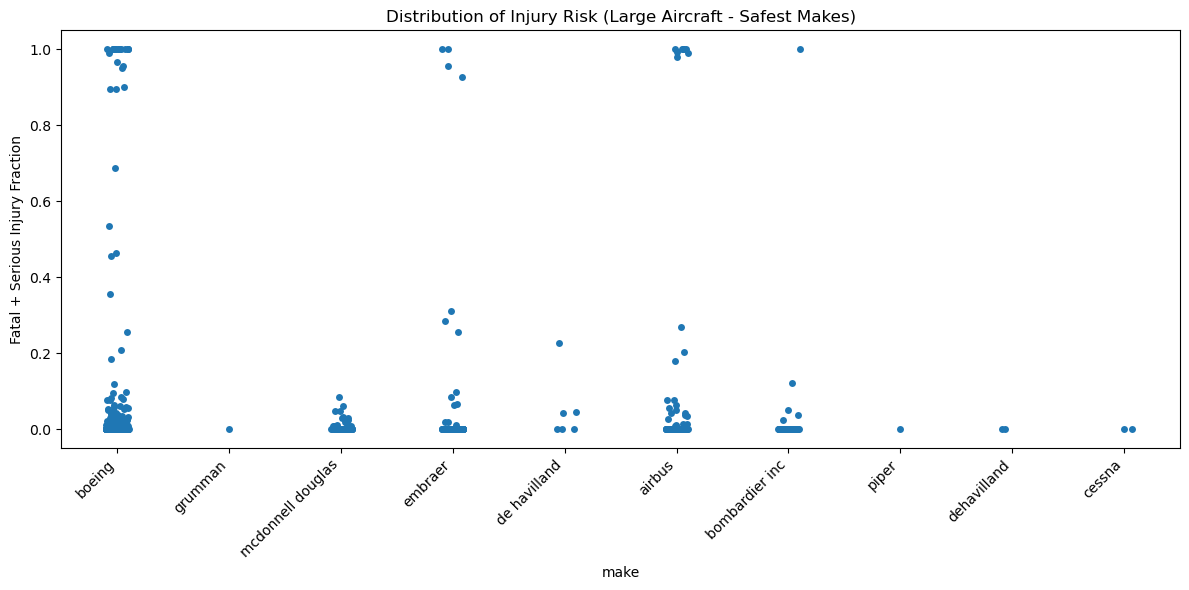

In [327]:
plt.figure(figsize=(12, 6))

sns.stripplot(
    data=large_df[large_df["make"].isin(large_safest["make"])],
    x="make",
    y="fatal_serious_fraction",
    jitter=True
)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Injury Risk (Large Aircraft - Safest Makes)")
plt.ylabel("Fatal + Serious Injury Fraction")

plt.tight_layout()
plt.savefig("visualizations/injury_large_risk.png")
plt.show()

i will recommend bombadier inc and de havilland

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [294]:
small_df = df_filtered[df_filtered["aircraft_size"] == "small"]

top 10 small planes

In [295]:
small_safest = (
    small_df.groupby("make")["fatal_serious_fraction"]
    .mean()
    .sort_values()
    .head(10)
    .reset_index()
)

violinplot for small planes

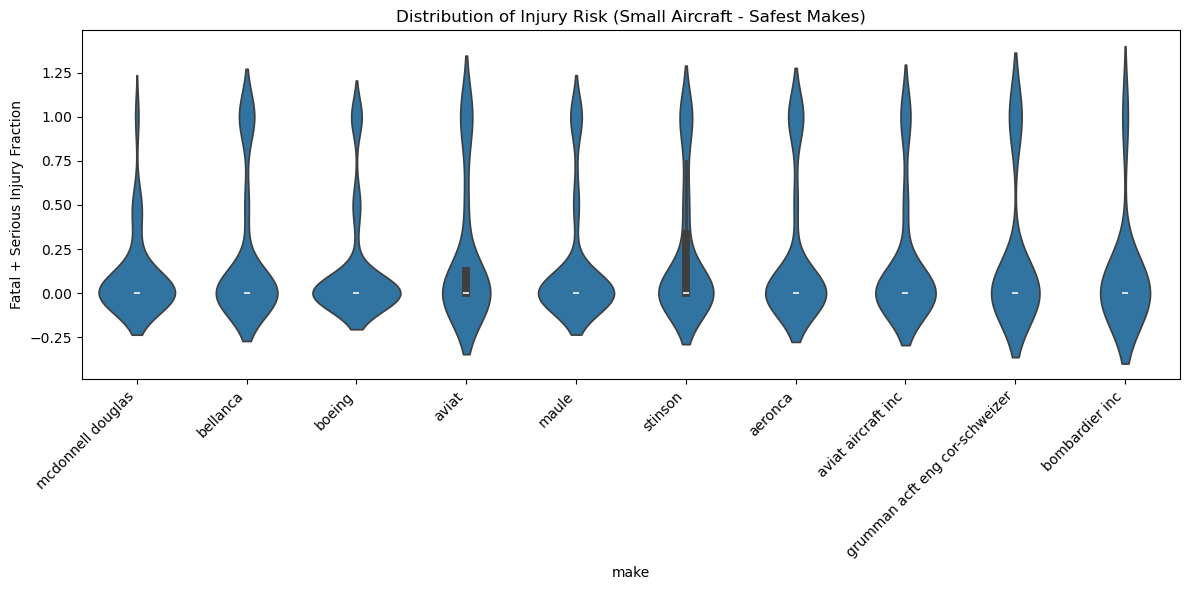

In [326]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=small_df[small_df["make"].isin(small_safest["make"])],
    x="make",
    y="fatal_serious_fraction"
)

plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Injury Risk (Small Aircraft - Safest Makes)")
plt.ylabel("Fatal + Serious Injury Fraction")

plt.tight_layout()
plt.savefig("visualizations/injury_risk.png")
plt.show()

bombardier inc and aviat are the best planes

combined bar plot for small and large planes

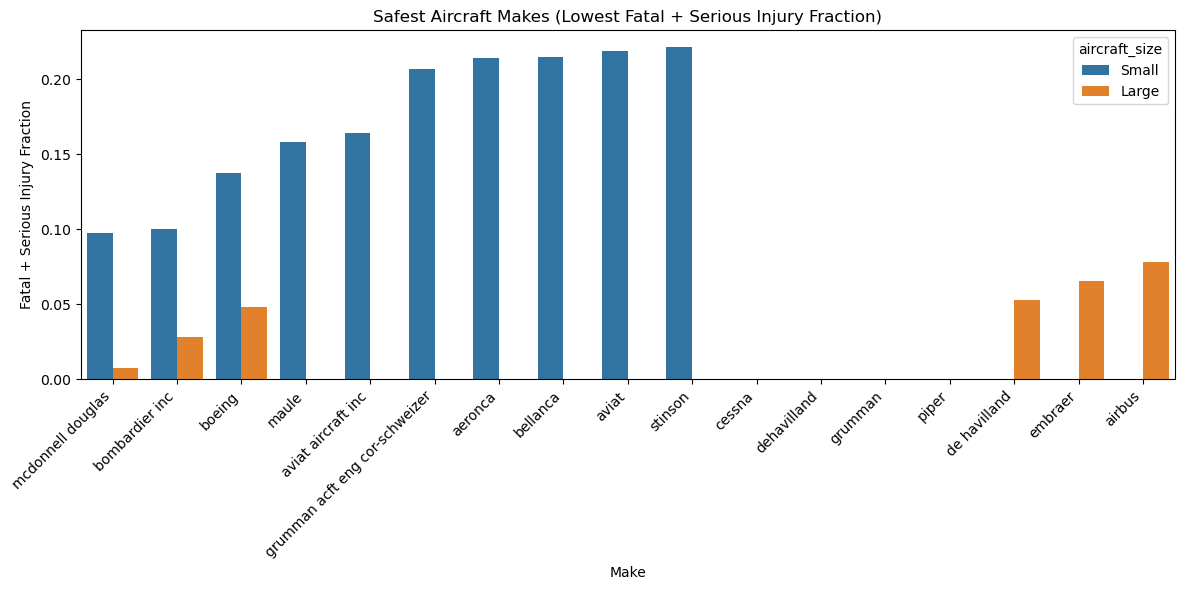

In [297]:
import matplotlib.pyplot as plt
import seaborn as sns

small_safest["aircraft_size"] = "Small"
large_safest["aircraft_size"] = "Large"

combined = pd.concat([small_safest, large_safest])

plt.figure(figsize=(12, 6))

sns.barplot(
    data=combined,
    x="make",
    y="fatal_serious_fraction",
    hue="aircraft_size"
)

plt.xticks(rotation=45, ha="right")
plt.title("Safest Aircraft Makes (Lowest Fatal + Serious Injury Fraction)")
plt.ylabel("Fatal + Serious Injury Fraction")
plt.xlabel("Make")

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

for large size aircraft i will recommend bombadir inc becaouse they have low inury risk , this is visualizes using stripplot

for small planes i will still recommend bombadier inc and aviat this was visualized using violin plot

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

how weather condition affects aircraft damage

comparing inury risk by weather

In [298]:
weather_injury = df.groupby("weather_condition").agg({
    "fatal_serious_fraction": "mean",
    "total_injuries": "mean",
    "event_id": "count"
}).rename(columns={"event_id": "total_accidents"}).reset_index()

weather_injury

,weather_condition,fatal_serious_fraction,total_injuries,total_accidents
0,imc,0.609697,2.226277,822
1,unknown,0.415010,3.734342,1916
2,vmc,0.227644,0.657174,13730


plot mean injury risk

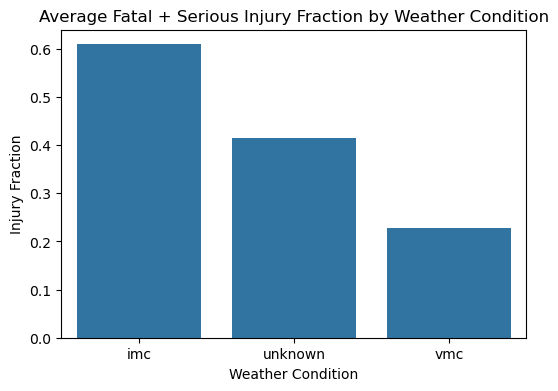

In [299]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=weather_injury,
    x="weather_condition",
    y="fatal_serious_fraction"
)

plt.title("Average Fatal + Serious Injury Fraction by Weather Condition")
plt.ylabel("Injury Fraction")
plt.xlabel("Weather Condition")

plt.show()

distribution of injury severity

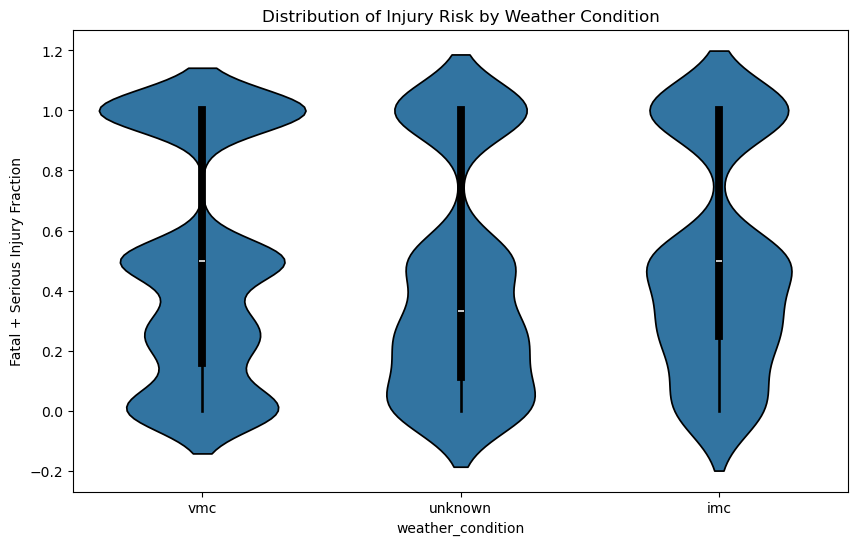

In [325]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="weather_condition",
    y="fatal_serious_fraction",
    edgecolor="black"
)

plt.title("Distribution of Injury Risk by Weather Condition")
plt.ylabel("Fatal + Serious Injury Fraction")
plt.savefig("visualizations/injury_weather.png")
plt.show()

vmc weather is the safest

analize aircraft destruction by weather

In [301]:
weather_damage = df.groupby("weather_condition").agg({
    "is_destroyed": "mean",
    "event_id": "count"
}).rename(columns={
    "is_destroyed": "destruction_rate",
    "event_id": "total_accidents"
}).reset_index()

weather_damage

,weather_condition,destruction_rate,total_accidents
0,imc,0.0,822
1,unknown,0.0,1916
2,vmc,0.0,13730


ploting destruction rate

In [302]:
df["is_destroyed"] = df["aircraft_damage"].apply(
    lambda x: 1 if x == "Destroyed" else 0
)

In [303]:
weather_damage = df.groupby("weather_condition").agg({
    "is_destroyed": "mean"
}).reset_index()

weather_damage.rename(columns={"is_destroyed": "destruction_rate"}, inplace=True)

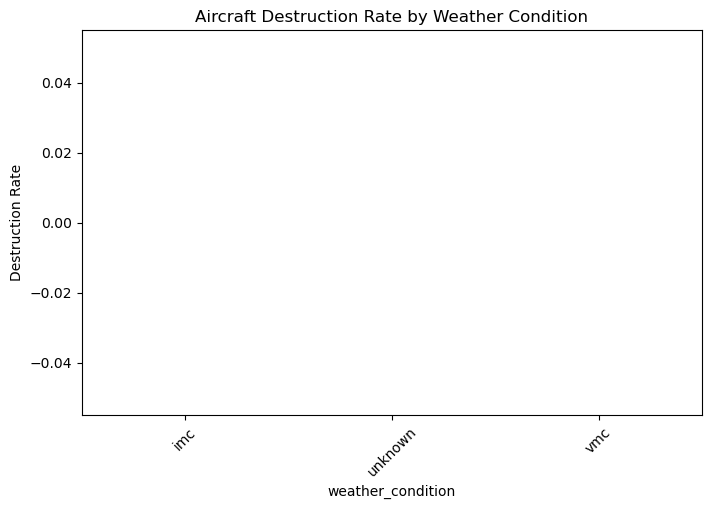

In [304]:
weather_damage["weather_condition"] = weather_damage["weather_condition"].fillna("Unknown")

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weather_damage,
    x="weather_condition",
    y="destruction_rate"
)

plt.title("Aircraft Destruction Rate by Weather Condition")
plt.ylabel("Destruction Rate")
plt.xticks(rotation=45)

plt.show()

1. Weather impact

“Accidents occurring in poor weather conditions (IMC) show higher fatal and serious injury rates compared to clear weather (VMC), indicating that environmental factors significantly increase risk.”

 2. Risk variability

“The distribution of injury severity is wider under poor weather, suggesting less predictability and higher extreme-risk scenarios.”

3. Aircraft damage

“Aircraft destruction rates are higher in adverse weather, reinforcing the compounding effect of environmental stress on accident severity.”

how purpose of flight affect aircraft damage and injury

In [305]:
#confirming if the columns exist
df.columns

Index(['event_id', 'investigation_type', 'accident_number', 'event_date',
       'location', 'country', 'latitude', 'longitude', 'injury_severity',
       'aircraft_damage', 'aircraft_category', 'registration_number', 'make',
       'model', 'amateur_built', 'number_of_engines', 'engine_type',
       'far_description', 'purpose_of_flight', 'total_fatal_injuries',
       'total_serious_injuries', 'total_minor_injuries', 'total_uninjured',
       'weather_condition', 'broad_phase_of_flight', 'publication_date',
       'total_passengers', 'fatal_injury_rate', 'serious_injury_rate',
       'severe_injury_rate', 'was_destroyed', 'Make', 'base_model',
       'aircraft_type', 'aircraft_size', 'total_injuries',
       'fatal_serious_fraction', 'is_destroyed'],
      dtype='object')

In [ ]:
df["is_destroyed"] = df["aircraft_damage"].apply(
    lambda x: 1 if x == "Destroyed" else 0
)#aircraft destruction indicator


In [312]:
# injury fraction
df["fatal_serious_total"] = (
    df['fatal_injury_rate'] + df['serious_injury_rate']
)

df["fatal_serious_fraction"] = (
    df["fatal_serious_total"] / df["total_passengers"]
)

In [314]:
#cleaning data
df["purpose_of_flight"] = df["purpose_of_flight"].fillna("Unknown")

df = df.dropna(subset=["fatal_serious_fraction"])

In [316]:
#aggregrate by purpose of flight
purpose_analysis = (
    df
    .groupby("purpose_of_flight")
    .agg({
        "is_destroyed": "mean",
        "fatal_serious_fraction": "mean",
        "purpose_of_flight": "count"
    })
    .rename(columns={"purpose_of_flight": "total_accidents"})
    .reset_index()
)
purpose_analysis = purpose_analysis[
    purpose_analysis["total_accidents"] >= 20
]#filter for reliability

plot bar graph of aircraft damage by purpose

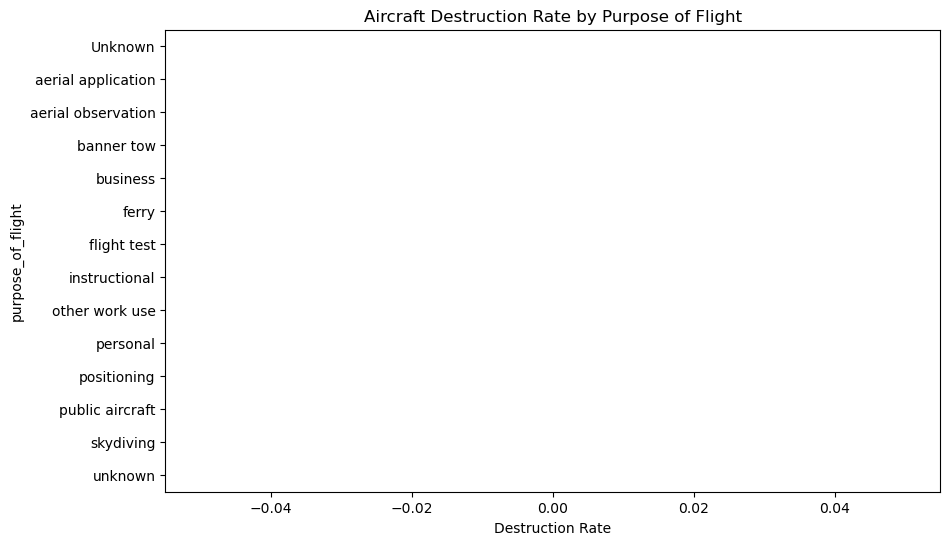

In [317]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=purpose_analysis.sort_values("is_destroyed"),
    x="is_destroyed",
    y="purpose_of_flight"
)

plt.title("Aircraft Destruction Rate by Purpose of Flight")
plt.xlabel("Destruction Rate")

plt.show()

plotting bar grapg of injury severity by purpose

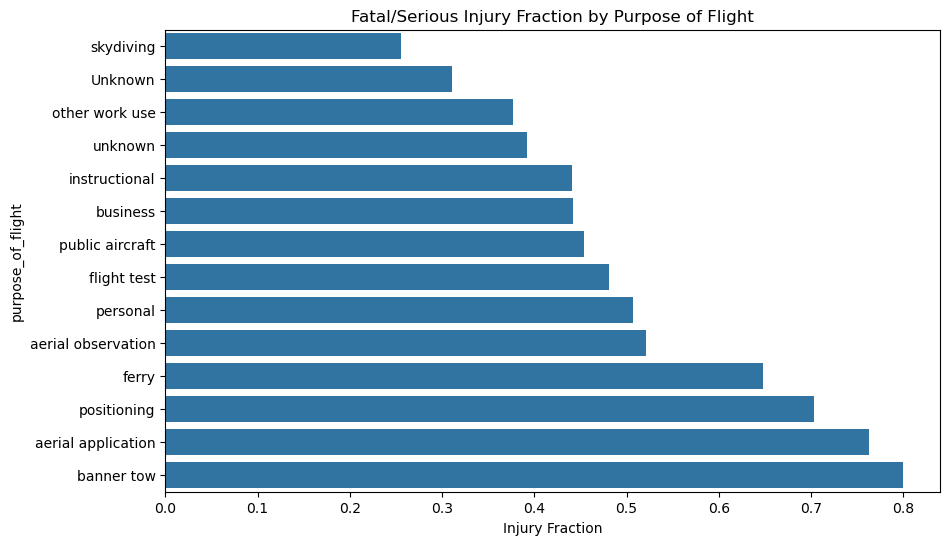

In [318]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=purpose_analysis.sort_values("fatal_serious_fraction"),
    x="fatal_serious_fraction",
    y="purpose_of_flight"
)

plt.title("Fatal/Serious Injury Fraction by Purpose of Flight")
plt.xlabel("Injury Fraction")

plt.show()

distribution plot of injury severity by purpose using bar graph

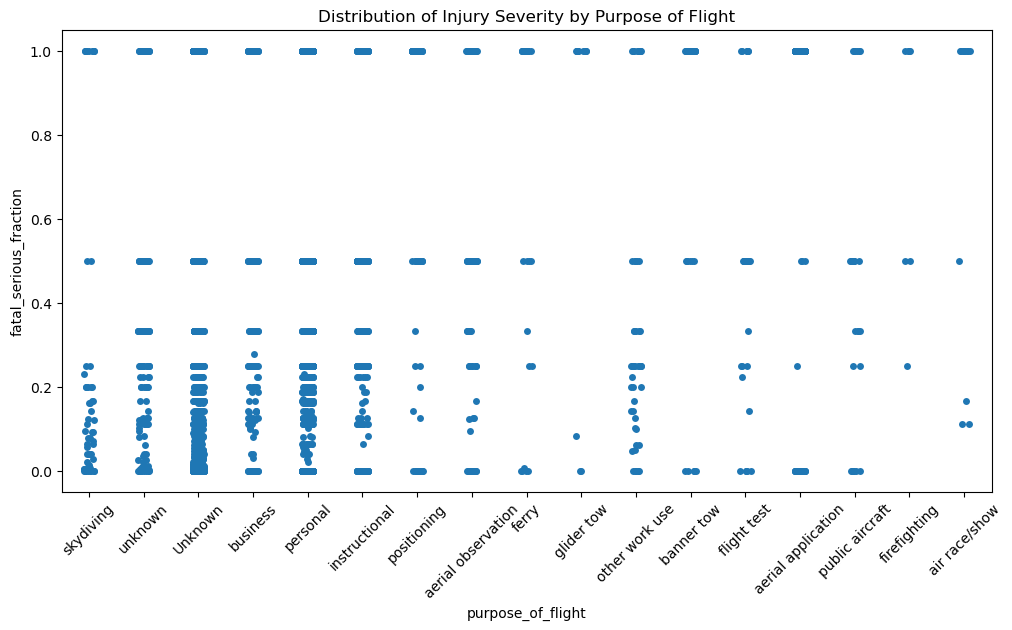

In [319]:
plt.figure(figsize=(12, 6))

sns.stripplot(
    data=df,
    x="purpose_of_flight",
    y="fatal_serious_fraction",
    jitter=True
)

plt.xticks(rotation=45)
plt.title("Distribution of Injury Severity by Purpose of Flight")

plt.show()

checking on how weeather affect aircraft damage and inury, i found that VMC weather is the safest.i used violinplot and bargraph to visualize
the safest purpose of flight is skydiving, i visualized this using  a bar graph.

Purpose of flight significantly impacts both aircraft damage and injury severity. Non-commercial operations such as personal and instructional flights tend to exhibit higher variability and elevated injury fractions. In contrast, commercial flights generally show lower destruction rates and tighter distributions, reflecting stricter safety protocols and regulation.